In [1]:
import numpy as np
from numpy.linalg import eigvals
from energyflow import EFPSet
from energyflow.utils import gen_massless_phase_space
import matplotlib.pyplot as plt

# Look at standard EFP package covariances on uniform phase space of various particle numbers

In [2]:
NEvents=10000
uniform_N3 = gen_massless_phase_space(NEvents,3,energy=1.0)
uniform_N5 = gen_massless_phase_space(NEvents,5,energy=1.0)
uniform_N7 = gen_massless_phase_space(NEvents,7,energy=1.0)
uniform_N9 = gen_massless_phase_space(NEvents,9,energy=1.0)

In [3]:
efpset = EFPSet(('d<=', 6), measure='eeefm', beta=2,coords='epxpypz')

In [4]:
EFPs_N3 = efpset.batch_compute(uniform_N3)
EFPs_N5 = efpset.batch_compute(uniform_N5)
EFPs_N7 = efpset.batch_compute(uniform_N7)
EFPs_N9 = efpset.batch_compute(uniform_N9)

In [5]:
EFP_cov_N3 = (1/NEvents)*np.einsum('ij,ik->jk',EFPs_N3,EFPs_N3) - np.outer(EFPs_N3.mean(axis=0), EFPs_N3.mean(axis=0))
EFP_cov_N5 = (1/NEvents)*np.einsum('ij,ik->jk',EFPs_N5,EFPs_N5) - np.outer(EFPs_N5.mean(axis=0), EFPs_N5.mean(axis=0))
EFP_cov_N7 = (1/NEvents)*np.einsum('ij,ik->jk',EFPs_N7,EFPs_N7) - np.outer(EFPs_N7.mean(axis=0), EFPs_N7.mean(axis=0))
EFP_cov_N9 = (1/NEvents)*np.einsum('ij,ik->jk',EFPs_N9,EFPs_N9) - np.outer(EFPs_N9.mean(axis=0), EFPs_N9.mean(axis=0))

In [7]:
eigs_N3 = np.flip(np.sort(np.real(eigvals(EFP_cov_N3))))
eigs_N5 = np.flip(np.sort(np.real(eigvals(EFP_cov_N5))))
eigs_N7 = np.flip(np.sort(np.real(eigvals(EFP_cov_N7))))
eigs_N9 = np.flip(np.sort(np.real(eigvals(EFP_cov_N9))))

Text(0.5, 1.0, 'EFP covariance spectrum, uniform phase space')

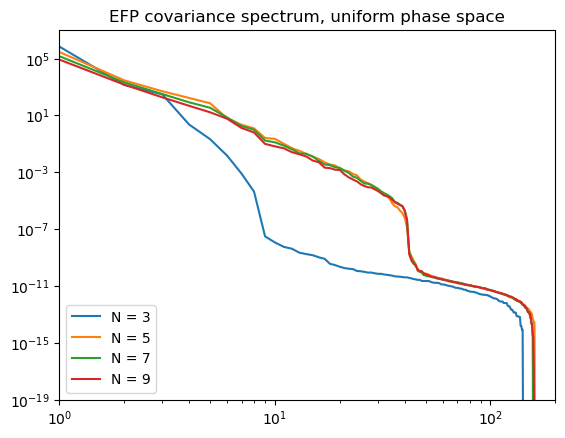

In [8]:
plt.plot(np.arange(1,eigs_N3.shape[0]+1,1),eigs_N3,label='N = 3')
plt.plot(np.arange(1,eigs_N5.shape[0]+1,1),eigs_N5,label='N = 5')
plt.plot(np.arange(1,eigs_N7.shape[0]+1,1),eigs_N7,label='N = 7')
plt.plot(np.arange(1,eigs_N9.shape[0]+1,1),eigs_N9,label='N = 9')
plt.yscale('log')
plt.xscale('log')
plt.xlim((1,200))
plt.ylim((1e-19,1e7))
plt.legend(loc='lower left')
plt.title('EFP covariance spectrum, uniform phase space')

# Compute covariance spectrum on restricted class of EFPs (from scratch since EFP package is slow)
Disclaimer: this part is written by Claude Code and not yet verified!!

In [9]:
def _compute_z_theta(events):
    """Energy fractions and pairwise angular weights with this notebook's conventions.

    For each event computes::

        z_i        = 2 E_i / sum_k E_k
        theta_{ij} = (1 - cos theta_{ij}) / 2

    where ``cos theta_{ij}`` is the cosine of the 3D angle between particles i and j
    (computed from the spatial momenta). Self-angles ``theta_{ii}`` are exactly zero.

    Parameters
    ----------
    events : ndarray, shape (NEvents, N, 4) or (N, 4)
        Particles in (E, px, py, pz) coordinates.

    Returns
    -------
    z : ndarray, shape (NEvents, N)
    theta : ndarray, shape (NEvents, N, N)
    """
    events = np.asarray(events, dtype=float)
    if events.ndim == 2:
        events = events[None]
    E  = events[..., 0]
    p3 = events[..., 1:4]
    z = 2.0 * E / E.sum(axis=-1, keepdims=True)
    pmag = np.linalg.norm(p3, axis=-1)
    pdot = np.einsum('...ia,...ja->...ij', p3, p3)
    denom = pmag[..., :, None] * pmag[..., None, :]
    cos_th = np.divide(pdot, denom, out=np.zeros_like(pdot), where=denom > 0)
    return z, 0.5 * (1.0 - cos_th)


def efp_type1_direct(events, m_max):
    """Type-1 EFPs (2-vertex, m parallel edges) for m = 2, 3, ..., m_max.

    Computed directly from the definition::

        EFP_m = sum_{i, j} z_i z_j theta_{ij}^m

    Returns
    -------
    out : ndarray, shape (NEvents, m_max - 1)
        out[..., k] is the EFP value for m = k + 2.
    """
    if m_max < 2:
        raise ValueError("m_max must be >= 2")
    z, th = _compute_z_theta(events)
    zz = z[..., :, None] * z[..., None, :]
    out = np.empty(z.shape[:1] + (m_max - 1,))
    Ap = th * th
    for k in range(m_max - 1):
        out[..., k] = (zz * Ap).sum(axis=(-2, -1))
        if k < m_max - 2:
            Ap = Ap * th
    return out


def efp_type2_direct(events, p_max, q_max):
    """Type-2 EFPs (3-vertex "V", p and q edges) for p in [2, p_max], q in [2, q_max].

    Computed directly from the definition::

        EFP_{p,q} = sum_{i, j, k} z_i z_j z_k theta_{ij}^p theta_{ik}^q

    Returns
    -------
    out : ndarray, shape (NEvents, p_max - 1, q_max - 1)
        out[..., a, b] is the EFP value for (p, q) = (a + 2, b + 2).
    """
    if p_max < 2 or q_max < 2:
        raise ValueError("p_max and q_max must both be >= 2")
    z, th = _compute_z_theta(events)
    max_pow = max(p_max, q_max)
    # s_cache[k] = sum_j z_j theta_{ij}^{k+2}, per event.
    s_cache = []
    Ap = th * th
    for k in range(max_pow - 1):
        s_cache.append((Ap * z[..., None, :]).sum(axis=-1))
        if k < max_pow - 2:
            Ap = Ap * th
    out = np.empty(z.shape[:1] + (p_max - 1, q_max - 1))
    for a in range(p_max - 1):
        for b in range(q_max - 1):
            out[..., a, b] = (z * s_cache[a] * s_cache[b]).sum(axis=-1)
    return out


def efp_type3_direct(events, r_max, s_max, t_max):
    """Type-3 EFPs (3-vertex triangle) for r in [1, r_max], s in [1, s_max], t in [1, t_max].

    Computed directly from the definition::

        EFP_{r,s,t} = sum_{i, j, k} z_i z_j z_k theta_{ij}^r theta_{ik}^s theta_{jk}^t

    Returns
    -------
    out : ndarray, shape (NEvents, r_max, s_max, t_max)
        out[..., a, b, c] is the EFP value for (r, s, t) = (a + 1, b + 1, c + 1).
    """
    if r_max < 1 or s_max < 1 or t_max < 1:
        raise ValueError("r_max, s_max, t_max must each be >= 1")
    z, th = _compute_z_theta(events)
    max_pow = max(r_max, s_max, t_max)
    A = [th]
    for _ in range(max_pow - 1):
        A.append(A[-1] * th)
    zz = z[..., :, None] * z[..., None, :]
    out = np.empty(z.shape[:1] + (r_max, s_max, t_max))
    # For each (s, t), precompute M_{s,t}[e, i, j] = sum_k z_k theta_{ik}^s theta_{jk}^t,
    # then accumulate over r. Since theta is symmetric, M = A^s @ (diag(z) A^t).
    for b in range(s_max):
        for c in range(t_max):
            M = A[b] @ (z[..., :, None] * A[c])
            for a in range(r_max):
                out[..., a, b, c] = (zz * A[a] * M).sum(axis=(-2, -1))
    return out


In [12]:
# Example: compute every special-graph EFP up to (m_max, (p_max, q_max), (r_max, s_max, t_max))
# in one shot for the N = 5 uniform events. Each call returns a single numpy array indexed
# by event and by the edge-count parameters.
T1 = efp_type1_direct(uniform_N5, m_max=8)              # shape (NEvents, 7)
T2 = efp_type2_direct(uniform_N5, p_max=8, q_max=8)     # shape (NEvents, 7, 7)
T3 = efp_type3_direct(uniform_N5, r_max=8, s_max=8, t_max=8)   # shape (NEvents, 8, 8, 8)
print("type 1 shape:", T1.shape)
print("type 2 shape:", T2.shape)
print("type 3 shape:", T3.shape)
print("\nFirst event, a few values:")
print("  EFP_2 (m=2):           ", T1[0, 0])
print("  EFP_{p=2,q=2}:         ", T2[0, 0, 0])
print("  EFP_{r=1,s=1,t=1}:     ", T3[0, 0, 0, 0])
print("  EFP_{r=2,s=1,t=1}:     ", T3[0, 1, 0, 0])


type 1 shape: (10000, 7)
type 2 shape: (10000, 7, 7)
type 3 shape: (10000, 8, 8, 8)

First event, a few values:
  EFP_2 (m=2):            1.4230891695717944
  EFP_{p=2,q=2}:          1.0152301957882355
  EFP_{r=1,s=1,t=1}:      0.8074658594725066
  EFP_{r=2,s=1,t=1}:      0.5616887598681133


In [13]:
# Covariance spectrum of the three special EFP families on N = 10 uniform phase space,
# with maximum total graph degree D_MAX = 10. The basis is built from unique graphs
# (sorted multiplicities), so (p, q) ~ (q, p) and permutations of (r, s, t) are not
# double-counted.
NEvents_10 = 10000
N_PARTICLES = 10
D_MAX = 16

uniform_N10 = gen_massless_phase_space(NEvents_10, N_PARTICLES, energy=1.0)

# Compute the full grids in one shot. Edge counts max out where they are still
# realizable under p + q <= D_MAX (so each of p, q is at most D_MAX - 2) and
# r + s + t <= D_MAX (so each of r, s, t is at most D_MAX - 2 as well).
T1_grid = efp_type1_direct(uniform_N10, D_MAX)
T2_grid = efp_type2_direct(uniform_N10, D_MAX - 2, D_MAX - 2)
T3_grid = efp_type3_direct(uniform_N10, D_MAX - 2, D_MAX - 2, D_MAX - 2)

# Unique-up-to-isomorphism column stacks under total-degree cut.
type1_cols = T1_grid                                          # m = 2, ..., D_MAX
type2_keys = [(p, q) for p in range(2, D_MAX + 1)
                     for q in range(p, D_MAX + 1) if p + q <= D_MAX]
type3_keys = [(r, s, t) for r in range(1, D_MAX + 1)
                        for s in range(r, D_MAX + 1)
                        for t in range(s, D_MAX + 1) if r + s + t <= D_MAX]
type2_cols = np.column_stack([T2_grid[:, p - 2, q - 2] for p, q in type2_keys])
type3_cols = np.column_stack([T3_grid[:, r - 1, s - 1, t - 1] for r, s, t in type3_keys])
all_cols   = np.column_stack([type1_cols, type2_cols, type3_cols])
print(f"basis sizes -- type1: {type1_cols.shape[1]}, type2: {type2_cols.shape[1]}, "
      f"type3: {type3_cols.shape[1]}, all: {all_cols.shape[1]}")


def cov_spectrum(X):
    """Centered covariance matrix of X (columns = features) and its sorted eigenvalues."""
    Nev = X.shape[0]
    mu = X.mean(axis=0)
    cov = X.T @ X / Nev - np.outer(mu, mu)
    cov = 0.5 * (cov + cov.T)
    return np.flip(np.sort(np.real(eigvals(cov))))


eigs_t1  = cov_spectrum(type1_cols)
eigs_t2  = cov_spectrum(type2_cols)
eigs_t3  = cov_spectrum(type3_cols)
eigs_all = cov_spectrum(all_cols)


basis sizes -- type1: 15, type2: 49, type3: 123, all: 187


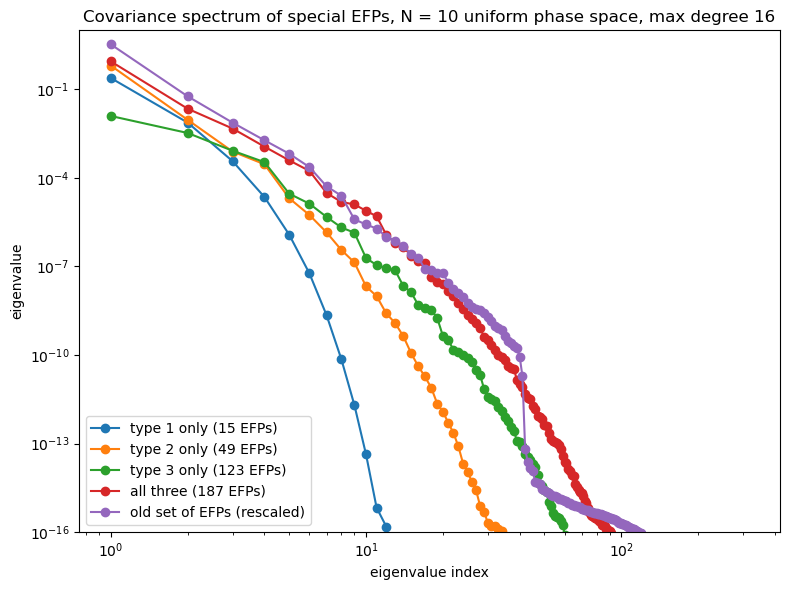

In [14]:
plt.figure(figsize=(8, 6))
for eigs, label in [
    (eigs_t1,  f"type 1 only ({len(eigs_t1)} EFPs)"),
    (eigs_t2,  f"type 2 only ({len(eigs_t2)} EFPs)"),
    (eigs_t3,  f"type 3 only ({len(eigs_t3)} EFPs)"),
    (eigs_all, f"all three ({len(eigs_all)} EFPs)"),
]:
    plt.plot(np.arange(1, len(eigs) + 1), eigs, marker="o", label=label)
plt.plot(np.arange(1,eigs_N9.shape[0]+1,1),4e-5*eigs_N9,marker="o",label='old set of EFPs (rescaled)')
plt.yscale("log")
plt.xscale("log")
plt.ylim(1e-16,10)
plt.xlabel("eigenvalue index")
plt.ylabel("eigenvalue")
plt.title(f"Covariance spectrum of special EFPs, N = {N_PARTICLES} uniform phase space, "
          f"max degree {D_MAX}")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


# Graveyard (random Claude Code stuff)

In [3]:
from collections import Counter


def classify_efp_graph(edges):
    """Classify an EFP graph as one of three special connected types.

    Type 1: 2-vertex graph with m >= 2 parallel edges.
    Type 2: 3-vertex "V" graph with edges only between vertex 1 and 2 (multiplicity p)
            and vertex 1 and 3 (multiplicity q), with p, q >= 2.
    Type 3: 3-vertex fully-connected graph with edge multiplicities r, s, t >= 1.

    Returns
    -------
    (graph_type, multiplicities) : (int, tuple) or (None, None)
        Multiplicities are returned sorted in descending order:
        (m,) for type 1, (p, q) for type 2, (r, s, t) for type 3.
    """
    if not edges:
        return None, None
    norm = [tuple(sorted(e)) for e in edges]
    counts = Counter(norm)
    vertices = {v for e in norm for v in e}
    nv = len(vertices)
    npairs = len(counts)
    mults = tuple(sorted(counts.values(), reverse=True))

    if nv == 2 and npairs == 1 and mults[0] >= 2:
        return 1, mults
    if nv == 3 and npairs == 2 and all(x >= 2 for x in mults):
        return 2, mults
    if nv == 3 and npairs == 3:
        return 3, mults
    return None, None


def find_special_efp_indices(efpset):
    """Map each special connected graph found in ``efpset`` to its column index.

    Returns
    -------
    dict
        Keys are ``(graph_type, multiplicities)`` tuples; values are the
        corresponding EFP column index in ``efpset``. Multiplicities are
        sorted in descending order so that e.g. (p, q) and (q, p) map to the
        same key.
    """
    index_map = {}
    for idx, g in enumerate(efpset.graphs()):
        gtype, params = classify_efp_graph(g)
        if gtype is not None:
            index_map.setdefault((gtype, params), idx)
    return index_map


In [4]:
def special_efp_covariance(efp_values, efpset, m=None, p=None, q=None, r=None, s=None, t=None):
    """Centered covariance matrix among selected special EFPs.

    Parameters
    ----------
    efp_values : ndarray, shape (N_events, N_efps)
        EFP values, e.g. produced by ``efpset.batch_compute(...)``.
    efpset : EFPSet
        The EFPSet whose columns correspond to ``efp_values``.
    m : int, optional
        Edge count for the type-1 graph (2 vertices, m parallel edges).
    p, q : int, optional
        Edge multiplicities for the type-2 graph (3-vertex "V"). Both must be given.
    r, s, t : int, optional
        Edge multiplicities for the type-3 graph (3-vertex triangle). All three must be given.

    Returns
    -------
    cov : ndarray
        Centered covariance matrix of the requested EFPs.
    labels : list[str]
        Human-readable label for each row/column of ``cov``.
    indices : list[int]
        EFP column indices that were selected.
    """
    index_map = find_special_efp_indices(efpset)
    requested = []
    if m is not None:
        requested.append((1, (m,), f"2-vert m={m}"))
    if p is not None and q is not None:
        key = tuple(sorted([p, q], reverse=True))
        requested.append((2, key, f"3-vert V (p,q)=({p},{q})"))
    if r is not None and s is not None and t is not None:
        key = tuple(sorted([r, s, t], reverse=True))
        requested.append((3, key, f"3-vert triangle (r,s,t)=({r},{s},{t})"))

    indices, labels = [], []
    for gtype, params, lbl in requested:
        if (gtype, params) not in index_map:
            raise ValueError(
                f"No EFP in efpset matches graph type {gtype} with multiplicities {params}; "
                f"it may exceed the EFPSet's maximum degree."
            )
        indices.append(index_map[(gtype, params)])
        labels.append(lbl)

    sub = efp_values[:, indices]
    N = sub.shape[0]
    cov = (sub.T @ sub) / N - np.outer(sub.mean(axis=0), sub.mean(axis=0))
    return cov, labels, indices


In [5]:
from energyflow import EFP


def special_efp_covariance_unbounded(events, m=None, p=None, q=None, r=None, s=None, t=None,
                                     measure='eeefm', beta=2, coords='epxpypz'):
    """Centered covariance matrix among the special EFPs, recomputed from scratch.

    Unlike :func:`special_efp_covariance`, this does not look up columns in a
    pre-built ``EFPSet`` (which silently caps at d <= 10 in the shipped library),
    so the requested edge counts may be arbitrarily large. Each EFP is
    instantiated directly from its edge list via :class:`energyflow.EFP` and
    evaluated on ``events``.

    Parameters
    ----------
    events : ndarray or sequence
        Event-level kinematic data accepted by ``EFP.batch_compute``.
    m : int, optional
        Edges for the type-1 graph (2 vertices, m parallel edges); requires m >= 2.
    p, q : int, optional
        Edges for the type-2 graph (3-vertex V); both required, both >= 2.
    r, s, t : int, optional
        Edges for the type-3 graph (3-vertex triangle); all three required, all >= 1.
    measure, beta, coords :
        Passed through to ``EFP(...)``.

    Returns
    -------
    cov : ndarray
        Centered covariance matrix among the constructed EFPs.
    labels : list[str]
    edge_lists : list[list[tuple]]
        Edge list used to construct each EFP.
    """
    requested = []
    if m is not None:
        if m < 2:
            raise ValueError(f"m must be >= 2, got {m}")
        requested.append(([(0, 1)] * m, f"2-vert m={m}"))
    if p is not None and q is not None:
        if p < 2 or q < 2:
            raise ValueError(f"p, q must be >= 2, got ({p}, {q})")
        requested.append(([(0, 1)] * p + [(0, 2)] * q, f"3-vert V (p,q)=({p},{q})"))
    if r is not None and s is not None and t is not None:
        if r < 1 or s < 1 or t < 1:
            raise ValueError(f"r, s, t must be >= 1, got ({r}, {s}, {t})")
        requested.append(([(0, 1)] * r + [(0, 2)] * s + [(1, 2)] * t,
                          f"3-vert triangle (r,s,t)=({r},{s},{t})"))
    if not requested:
        raise ValueError("Specify at least one graph: m, or both p and q, or all of r, s, t.")

    columns, labels, edge_lists = [], [], []
    for edges, lbl in requested:
        efp = EFP(edges, measure=measure, beta=beta, coords=coords)
        columns.append(efp.batch_compute(events))
        labels.append(lbl)
        edge_lists.append(edges)

    arr = np.column_stack(columns)
    N = arr.shape[0]
    cov = (arr.T @ arr) / N - np.outer(arr.mean(axis=0), arr.mean(axis=0))
    return cov, labels, edge_lists


In [6]:
# Same selection as the EFPSet-based demo, but recomputing from scratch.
cov_u, labels_u, edges_u = special_efp_covariance_unbounded(
    uniform_N5, m=3, p=2, q=2, r=2, s=1, t=1
)
for lbl, edges in zip(labels_u, edges_u):
    print(lbl, "  edges:", edges)
print("Covariance matrix:")
print(cov_u)

# Now push beyond the pre-computed EFPSet ceiling (d > 10):
# m=12, (p,q)=(6,6) so total degree 12, (r,s,t)=(4,4,4) so total degree 12.
cov_hi, labels_hi, _ = special_efp_covariance_unbounded(
    uniform_N5, m=12, p=6, q=6, r=4, s=4, t=4
)
print("\nHigh-degree covariance (d = 12 for each EFP):")
for lbl in labels_hi:
    print(" ", lbl)
print(cov_hi)


2-vert m=3   edges: [(0, 1), (0, 1), (0, 1)]
3-vert V (p,q)=(2,2)   edges: [(0, 1), (0, 1), (0, 2), (0, 2)]
3-vert triangle (r,s,t)=(2,1,1)   edges: [(0, 1), (0, 1), (0, 2), (1, 2)]
Covariance matrix:
[[  8.12562165  15.76676009  -8.78031926]
 [ 15.76676009  30.99356366 -17.12872704]
 [ -8.78031926 -17.12872704   9.76044583]]


KeyboardInterrupt: 